In [5]:
import pandas as pd
import numpy as np
import re
import ast

hotels = pd.read_csv(r"C:\Users\aleks\Downloads\hotels_test.csv\hotels_test.csv")
hotels.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520
3,Piazza Della Repubblica 17 Central Station 201...,241,10/17/2015,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,"[' Leisure trip ', ' Couple ', ' Ambassador Ju...",656 day,45.479888,9.196298
4,Singel 303 309 Amsterdam City Center 1012 WJ A...,834,5/16/2016,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,"[' Business trip ', ' Solo traveler ', ' Class...",444 day,52.370545,4.888644


# Работа с данными 

In [6]:
df_ml = hotels.copy()

In [7]:
# review_date - признаки
if 'review_date' in df_ml.columns:
    df_ml['review_date'] = pd.to_datetime(df_ml['review_date'], errors='coerce')
    df_ml['review_year'] = df_ml['review_date'].dt.year
    df_ml['review_month'] = df_ml['review_date'].dt.month
    df_ml['review_day'] = df_ml['review_date'].dt.day
    df_ml['review_dayofweek'] = df_ml['review_date'].dt.dayofweek
    df_ml['review_quarter'] = df_ml['review_date'].dt.quarter

# days_since_review - число
if 'days_since_review' in df_ml.columns:
    df_ml['days_since_review'] = (
        df_ml['days_since_review']
        .astype(str)
        .str.extract(r'(\d+)')[0]
        .astype(float)
    )

# Признаки из negative_review
if 'negative_review' in df_ml.columns:
    df_ml['negative_review'] = df_ml['negative_review'].fillna('')
    df_ml['neg_len'] = df_ml['negative_review'].str.len()
    df_ml['neg_words'] = df_ml['negative_review'].str.split().str.len()
    df_ml['neg_no_text'] = df_ml['negative_review'].str.contains('No Negative', case=False, na=False).astype(int)

# Признаки из positive_review
if 'positive_review' in df_ml.columns:
    df_ml['positive_review'] = df_ml['positive_review'].fillna('')
    df_ml['pos_len'] = df_ml['positive_review'].str.len()
    df_ml['pos_words'] = df_ml['positive_review'].str.split().str.len()
    df_ml['pos_no_text'] = df_ml['positive_review'].str.contains('No Positive', case=False, na=False).astype(int)

# Признаки из tags
def parse_tags(x):
    try:
        lst = ast.literal_eval(x)
        if isinstance(lst, list):
            return [str(i).strip() for i in lst]
    except:
        pass
    return []

if 'tags' in df_ml.columns:
    df_ml['tags'] = df_ml['tags'].astype(str)
    df_ml['tags_list'] = df_ml['tags'].apply(parse_tags)
    df_ml['tags_count'] = df_ml['tags_list'].apply(len)
    df_ml['is_business'] = df_ml['tags'].str.contains('Business trip', case=False, na=False).astype(int)
    df_ml['is_leisure'] = df_ml['tags'].str.contains('Leisure trip', case=False, na=False).astype(int)
    df_ml['is_couple'] = df_ml['tags'].str.contains('Couple', case=False, na=False).astype(int)
    df_ml['is_solo'] = df_ml['tags'].str.contains('Solo traveler', case=False, na=False).astype(int)
    df_ml['is_family'] = df_ml['tags'].str.contains('Family', case=False, na=False).astype(int)
    df_ml['is_mobile'] = df_ml['tags'].str.contains('mobile device', case=False, na=False).astype(int)

# Признаки из hotel_address
if 'hotel_address' in df_ml.columns:
    df_ml['hotel_address'] = df_ml['hotel_address'].fillna('')
    df_ml['address_len'] = df_ml['hotel_address'].str.len()
    df_ml['address_has_digits'] = df_ml['hotel_address'].str.contains(r'\d', na=False).astype(int)

    df_ml['country_from_address'] = df_ml['hotel_address'].str.split().str[-1]

# Координаты
if 'latlng' in df_ml.columns:
    if df_ml['latlng'].dtype == object:
        tmp = df_ml['latlng'].astype(str).str.extract(r'(-?\d+\.\d+)\s*,\s*(-?\d+\.\d+)')
        df_ml['lat'] = pd.to_numeric(tmp[0], errors='coerce')
        df_ml['lng'] = pd.to_numeric(tmp[1], errors='coerce')

# Дополнительные числовые признаки
if 'average_score' in df_ml.columns and 'reviewer_score' in df_ml.columns:
    df_ml['score_diff'] = df_ml['reviewer_score'] - df_ml['average_score']

if 'review_total_negative_word_count' in df_ml.columns and 'review_total_positive_word_count' in df_ml.columns:
    df_ml['total_review_words'] = (
        df_ml['review_total_negative_word_count'].fillna(0) +
        df_ml['review_total_positive_word_count'].fillna(0)
    )

if 'total_number_of_reviews' in df_ml.columns and 'total_number_of_reviews_reviewer_has_given' in df_ml.columns:
    df_ml['review_activity_ratio'] = (
        df_ml['total_number_of_reviews_reviewer_has_given'].fillna(0) /
        df_ml['total_number_of_reviews'].replace(0, np.nan)
    )

# Заполнение пропусков
num_cols = df_ml.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_ml[col] = df_ml[col].fillna(df_ml[col].median())

# Удаление ненужных столбцов
drop_cols = [
    'review_date', 'negative_review', 'positive_review',
    'tags', 'tags_list', 'hotel_address',
    'hotel_name', 'reviewer_nationality',
    'country_from_address', 'latlng'
]
df_ml = df_ml.drop(columns=drop_cols, errors='ignore')

# Проверка результата
print(df_ml.info())
print(df_ml.isna().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 30 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                128935 non-null  int64  
 1   average_score                               128935 non-null  float64
 2   review_total_negative_word_counts           128935 non-null  int64  
 3   total_number_of_reviews                     128935 non-null  int64  
 4   review_total_positive_word_counts           128935 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  128935 non-null  int64  
 6   days_since_review                           128935 non-null  float64
 7   lat                                         128935 non-null  float64
 8   lng                                         128935 non-null  float64
 9   review_year                                 128935 non-null  int32  
 

In [ ]:
import numpy as np
import pandas as pd
# матрицу корреляций Пирсона между всеми числовыми колонками 
corr = df_ml.corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print('Количество признаков к удалению:', len(to_drop))
print(to_drop)

Количество признаков к удалению: 5
['review_quarter', 'neg_len', 'neg_words', 'pos_len', 'pos_words']


In [10]:
df_ml_reduced = df_ml.drop(columns=to_drop, errors='ignore')
print(df_ml_reduced.shape)

(128935, 25)


In [12]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import f_regression, chi2
from sklearn.preprocessing import MinMaxScaler

df_feat = df_ml.copy()

y = df_feat['average_score']
X = df_feat.drop(columns=['average_score'])

# Числовые признаки - ANOVA
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[num_cols].copy().fillna(X[num_cols].median())

f_vals, p_vals = f_regression(X_num, y)

anova_df = pd.DataFrame({
    'feature': num_cols,
    'f_value': f_vals,
    'p_value': p_vals
}).sort_values('p_value')

print('ANOVA:')
print(anova_df.head(20))

# Категориальные признаки - chi2
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(cat_cols) > 0:
    X_cat = X[cat_cols].copy().fillna('missing')
    X_cat = pd.get_dummies(X_cat, drop_first=False)

    # неотрицательные значения
    X_cat = MinMaxScaler().fit_transform(X_cat)

    chi_vals, chi_p_vals = chi2(X_cat, y)

    chi_df = pd.DataFrame({
        'feature': pd.get_dummies(X[cat_cols].fillna('missing'), drop_first=False).columns,
        'chi2': chi_vals,
        'p_value': chi_p_vals
    }).sort_values('p_value')

    print('\nCHI-SQUARE:')
    print(chi_df.head(20))
else:
    print('\nКатегориальных признаков нет.')

ANOVA:
                                       feature      f_value        p_value
0                 additional_number_of_scoring  3083.119065   0.000000e+00
1            review_total_negative_word_counts  1574.436864   0.000000e+00
2                      total_number_of_reviews  4201.110696   0.000000e+00
3            review_total_positive_word_counts  1502.433199   0.000000e+00
6                                          lat  1617.767528   0.000000e+00
15                                 neg_no_text  2317.242658   0.000000e+00
26                                 address_len  1566.640537   0.000000e+00
16                                     pos_len  1707.051595   0.000000e+00
7                                          lng  1464.823509  1.076806e-318
13                                     neg_len  1460.051434  1.141451e-317
14                                   neg_words  1440.567381  1.754625e-313
17                                   pos_words  1412.385563  2.000143e-307
22                

In [13]:
corr = df_ml.drop(columns=['average_score']).corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print('Удаляемые признаки:')
print(to_drop)

df_ml_final = df_ml.drop(columns=to_drop, errors='ignore')
print(df_ml_final.shape)

Удаляемые признаки:
['review_quarter', 'neg_len', 'neg_words', 'pos_len', 'pos_words']
(128935, 25)


In [15]:
df_ml_final.head()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,days_since_review,lat,lng,review_year,...,tags_count,is_business,is_leisure,is_couple,is_solo,is_family,is_mobile,address_len,address_has_digits,review_activity_ratio
0,904,8.1,52,16670,62,1,13.0,45.533137,9.171102,2017,...,4,0,1,1,0,0,0,34,1,0.000060
1,612,8.6,10,5018,0,7,234.0,52.385649,4.834443,2016,...,4,0,1,0,0,0,0,53,1,0.001395
2,46,8.3,3,351,5,15,616.0,41.393192,2.161520,2015,...,5,1,0,0,1,0,1,43,1,0.042735
3,241,9.1,0,1543,27,9,656.0,45.479888,9.196298,2015,...,4,0,1,1,0,0,0,60,1,0.005833
4,834,9.1,0,4687,7,2,444.0,52.370545,4.888644,2016,...,5,1,0,0,1,0,1,66,1,0.000427


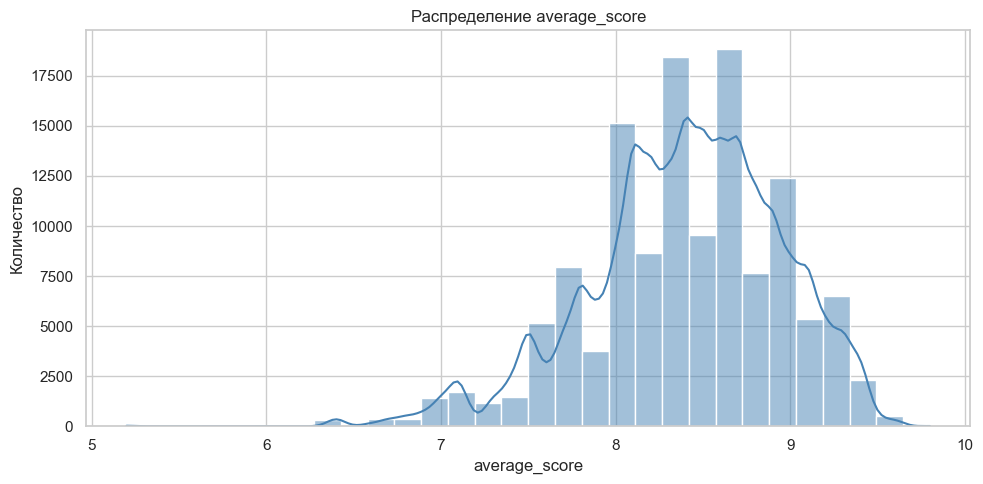

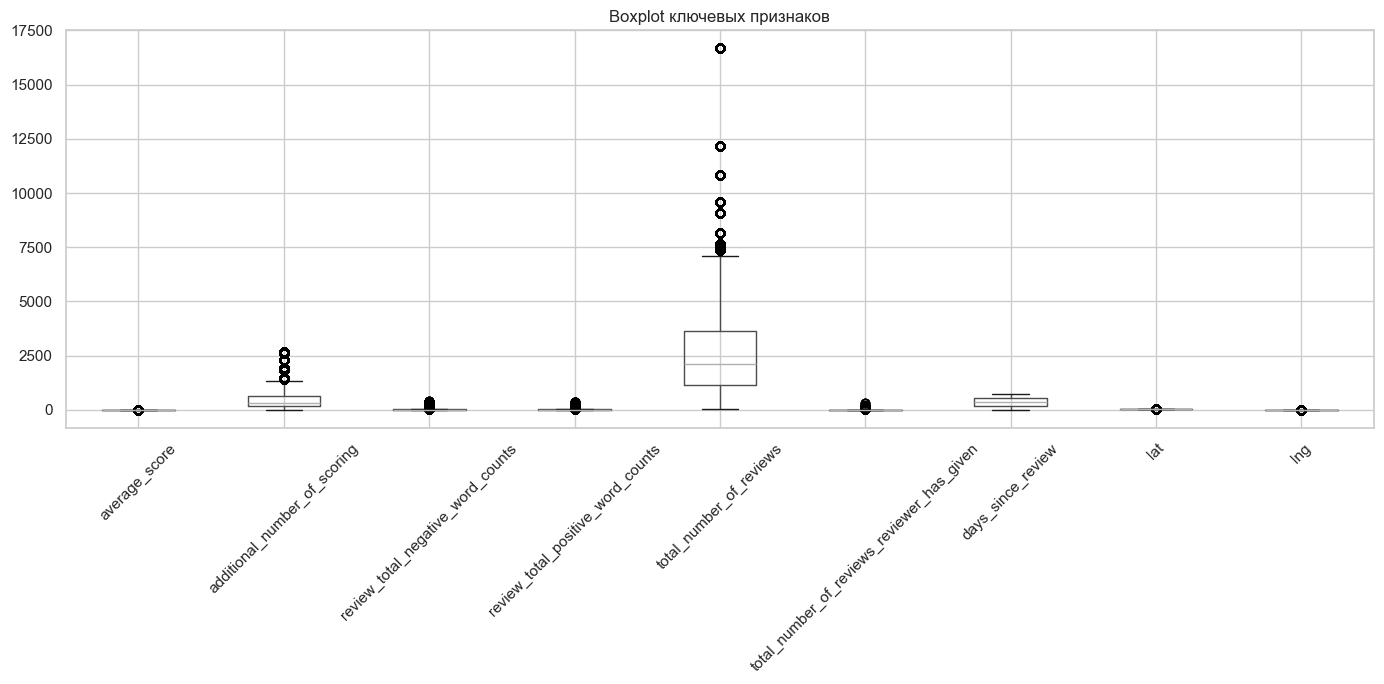

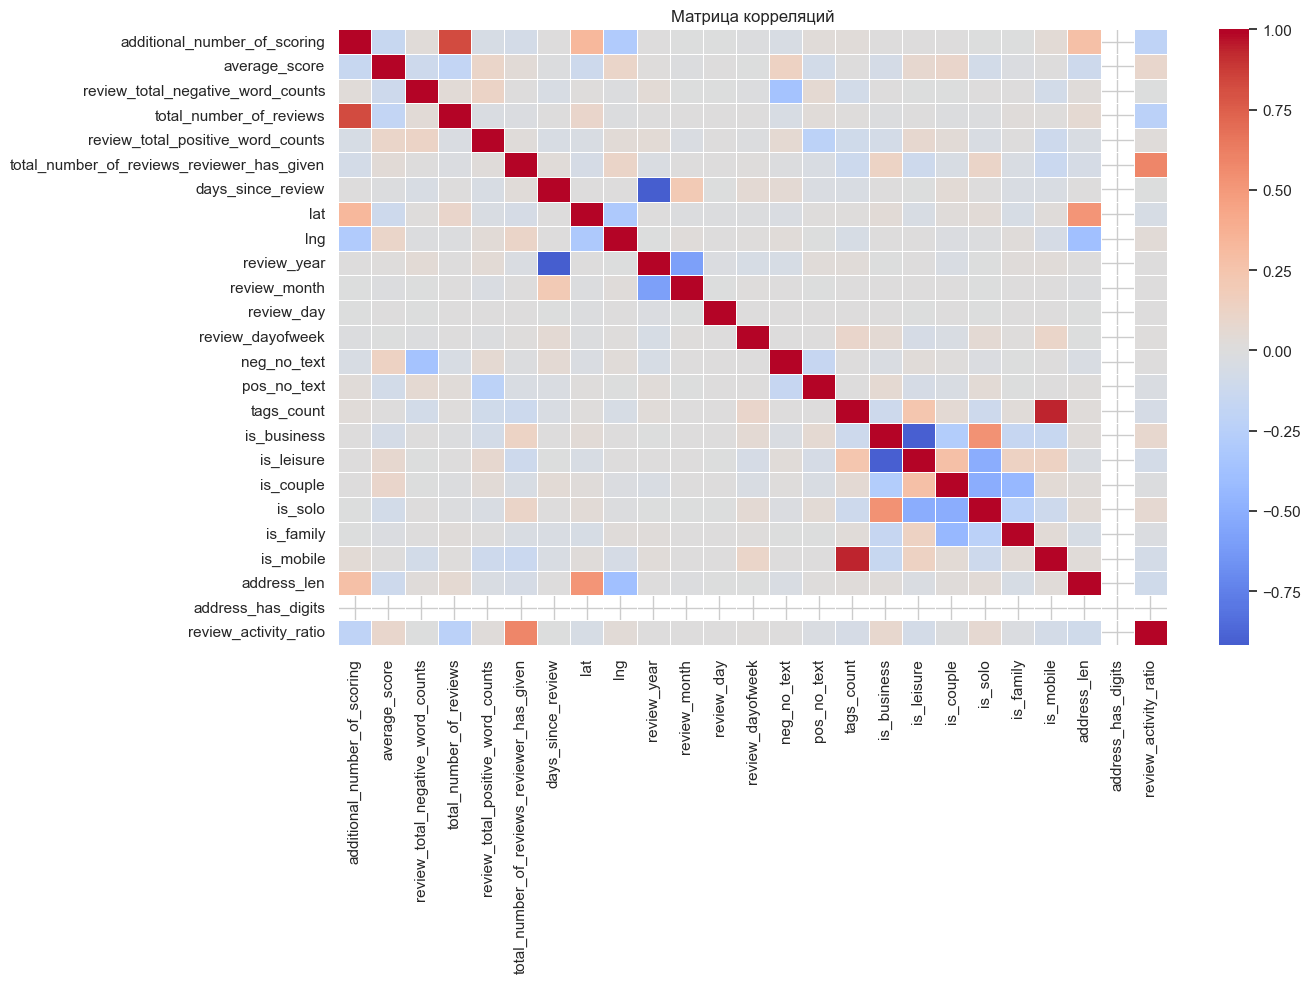

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
# Распределение average_score
plt.figure(figsize=(10, 5))
sns.histplot(df_ml_final['average_score'], bins=30, kde=True, color='steelblue')
plt.title('Распределение average_score')
plt.xlabel('average_score')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

# Boxplot по ключевым признакам
key_cols = [
    'average_score',
    'additional_number_of_scoring',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews',
    'total_number_of_reviews_reviewer_has_given',
    'days_since_review',
    'lat',
    'lng'
]

existing_cols = [col for col in key_cols if col in df_ml_final.columns]

plt.figure(figsize=(14, 7))
df_ml_final[existing_cols].boxplot(rot=45)
plt.title('Boxplot ключевых признаков')
plt.tight_layout()
plt.show()
# Heatmap корреляций
plt.figure(figsize=(14, 10))
corr = df_ml_final.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

In [18]:
table_score = df_ml_final['average_score'].describe().to_frame().T
table_score

,count,mean,std,min,25%,50%,75%,max
average_score,128935.0,8.398255,0.548551,5.2,8.1,8.4,8.8,9.8


In [19]:
key_cols = [
    'average_score',
    'additional_number_of_scoring',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews',
    'total_number_of_reviews_reviewer_has_given',
    'days_since_review',
    'lat',
    'lng'
]

existing_cols = [col for col in key_cols if col in df_ml_final.columns]

table_box = df_ml_final[existing_cols].describe().T
table_box

,count,mean,std,min,25%,50%,75%,max
average_score,128935.0,8.398255,0.548551,5.200000,8.100000,8.400000,8.800000,9.800000
additional_number_of_scoring,128935.0,497.587738,501.380503,1.000000,169.000000,341.000000,660.000000,2682.000000
review_total_negative_word_counts,128935.0,18.540838,29.653299,0.000000,2.000000,9.000000,23.000000,402.000000
review_total_positive_word_counts,128935.0,17.774879,22.036743,0.000000,5.000000,11.000000,22.000000,383.000000
total_number_of_reviews,128935.0,2742.999651,2320.494608,43.000000,1160.000000,2130.000000,3633.000000,16670.000000
total_number_of_reviews_reviewer_has_given,128935.0,7.132253,10.997515,1.000000,1.000000,3.000000,8.000000,315.000000
days_since_review,128935.0,354.603793,208.787640,0.000000,176.000000,353.000000,527.000000,730.000000
lat,128935.0,49.452295,3.457352,41.328376,48.214662,51.499981,51.516191,52.400181
lng,128935.0,2.807107,4.571480,-0.369758,-0.142745,0.010607,4.824952,16.429233


In [20]:
corr = df_ml_final.corr(numeric_only=True).abs()

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

pairs.columns = ['feature_1', 'feature_2', 'corr']
pairs = pairs.sort_values('corr', ascending=False)

pairs.head(20)

,feature_1,feature_2,corr
245,tags_count,is_mobile,0.938075
125,days_since_review,review_year,0.916998
248,is_business,is_leisure,0.903702
2,additional_number_of_scoring,total_number_of_reviews,0.826129
122,total_number_of_reviews_reviewer_has_given,review_activity_ratio,0.581666
171,review_year,review_month,0.580914
250,is_business,is_solo,0.528532
154,lat,address_len,0.515781
256,is_leisure,is_solo,0.508461
261,is_couple,is_solo,0.507371


# Обучение модели 

In [22]:
X = df_ml_final.drop(['average_score'], axis = 1)  
y = df_ml_final['average_score']  
       
from sklearn.model_selection import train_test_split  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
      
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  

y_pred = regr.predict(X_test)

In [23]:
# модель
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.00010312356696126084
